# Preparation

In [1]:
from pprint import pprint
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from matplotlib import pyplot as plt
import os
from datasets.data_processing import preprocess_df
from datasets.telco import load_telco_df
from gragod import start_research
from gragod.metrics.calculator import MetricsCalculator, get_metrics
from gragod.metrics.visualization import plot_single_score_histogram
from gragod.predictions.prediction import get_threshold_system
from gragod.predictions.spot import SPOT
from gragod.training import load_params
from gragod.types import Datasets, Models, ParamFileTypes
from models.predict import predict

Working on /Users/gonza/facultad/tesis/GraGOD
Loaded .env file: False


In [4]:
dataset = Datasets.TELCO.value


def load_dataset_predictions(model_name: str, dataset_name: str, split: str = "test"):
    data_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_data.pt"
    labels_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_labels.pt"
    output_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_output.pt"
    predictions_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_predictions.pt"
    scores_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_scores.pt"
    threshold_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_thresholds.pt"

    data = torch.load(data_path)
    labels = torch.load(labels_path)
    output = torch.load(output_path)
    predictions = torch.load(predictions_path)
    scores = torch.load(scores_path)
    threshold = torch.load(threshold_path)

    labels_single = (torch.sum(labels, dim=1) > 0).int()
    predictions_single = (torch.sum(predictions, dim=1) > 0).int()
    scores_single = torch.mean(scores, dim=1)

    return (
        data,
        labels,
        output,
        predictions,
        scores,
        labels_single,
        scores_single,
        predictions_single,
        threshold,
    )


def load_graph_model_predictions(
    model_name: str, dataset_name: str, split: str = "test"
):
    data_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_data.pt"
    labels_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_labels.pt"
    output_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_output.pt"
    predictions_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_predictions.pt"
    scores_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_scores.pt"
    threshold_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_thresholds.pt"

    data = torch.load(data_path)
    labels = torch.load(labels_path)
    output = torch.load(output_path)
    predictions = torch.load(predictions_path)
    scores = torch.load(scores_path)
    threshold = torch.load(threshold_path)

    labels_single = (torch.sum(labels, dim=1) > 0).int()
    predictions_single = (torch.sum(predictions, dim=1) > 0).int()
    scores_single = torch.mean(scores, dim=1)[0]

    return (
        data,
        labels,
        output,
        predictions,
        scores,
        labels_single,
        scores_single,
        predictions_single,
        threshold,
    )


from collections import defaultdict
models_outputs = defaultdict(dict)
for datasets in ["telco", "swat"]:
    for model in ["gru", "mtad_gat", "gdn", "gcn"]:
        data, labels, output, predictions, scores, labels_single, scores_single, predictions_single, threshold = load_dataset_predictions(model, datasets, split="test")
        models_outputs[datasets][model] = {
            "data": data,
            "labels": labels,
            "output": output,
            "predictions": predictions,
            "scores": scores,
            "labels_single": labels_single,
            "scores_single": scores_single,
            "predictions_single": predictions_single,
            "threshold": threshold,
        }

gru
mtad_gat
gdn
gcn
gru
mtad_gat
gdn
gcn


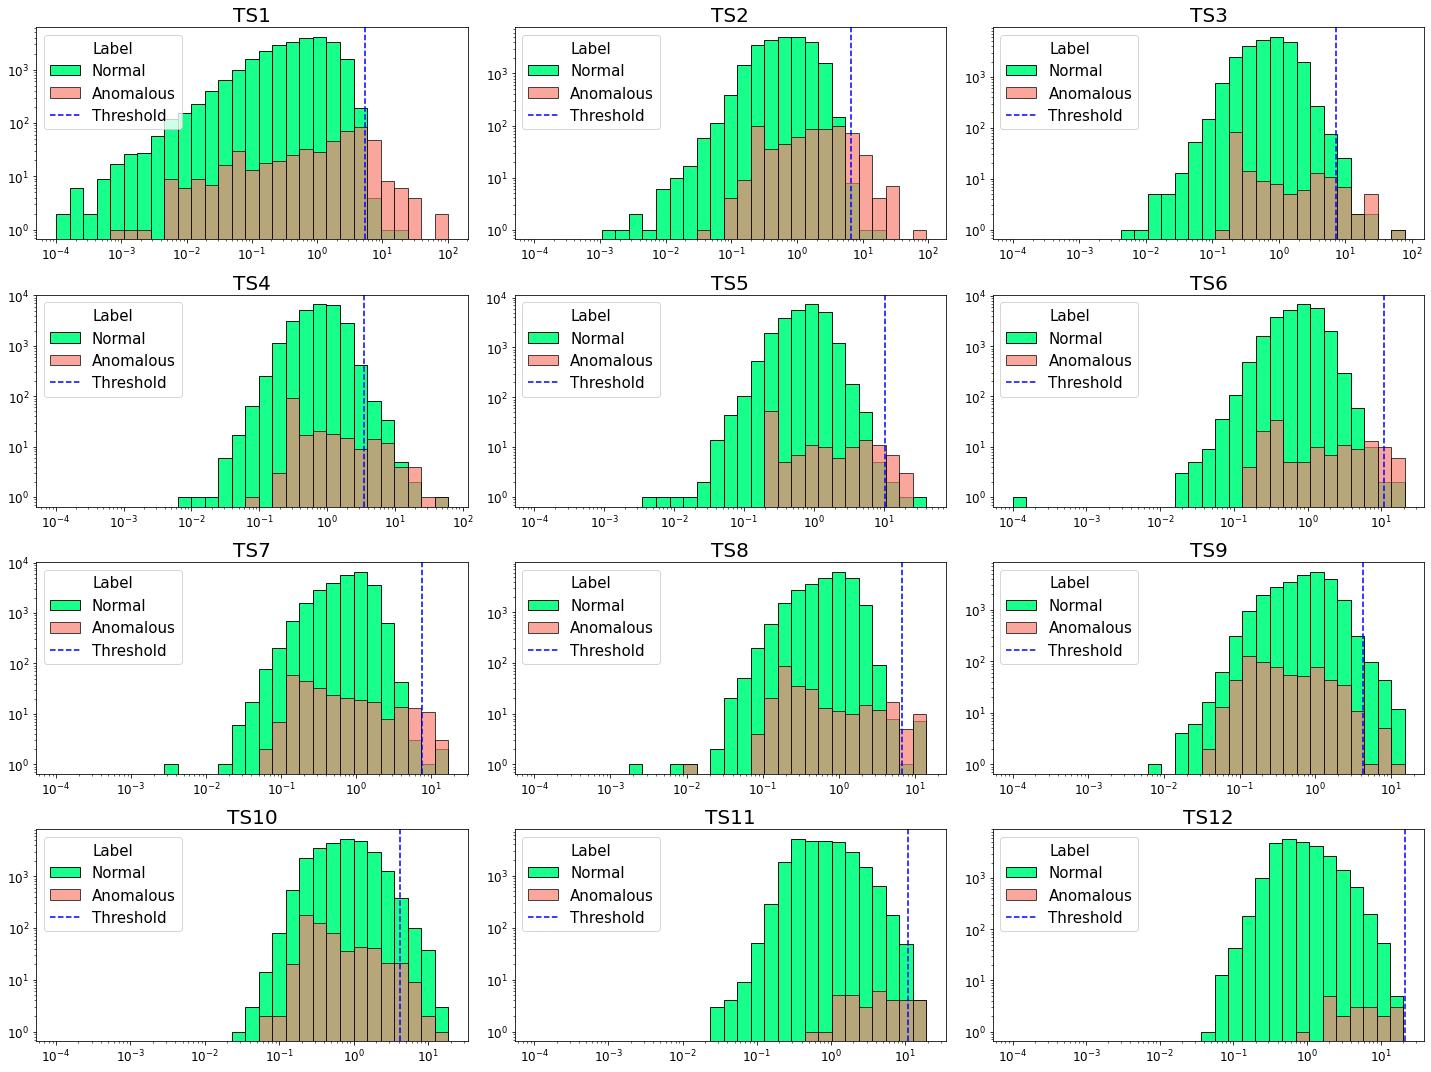

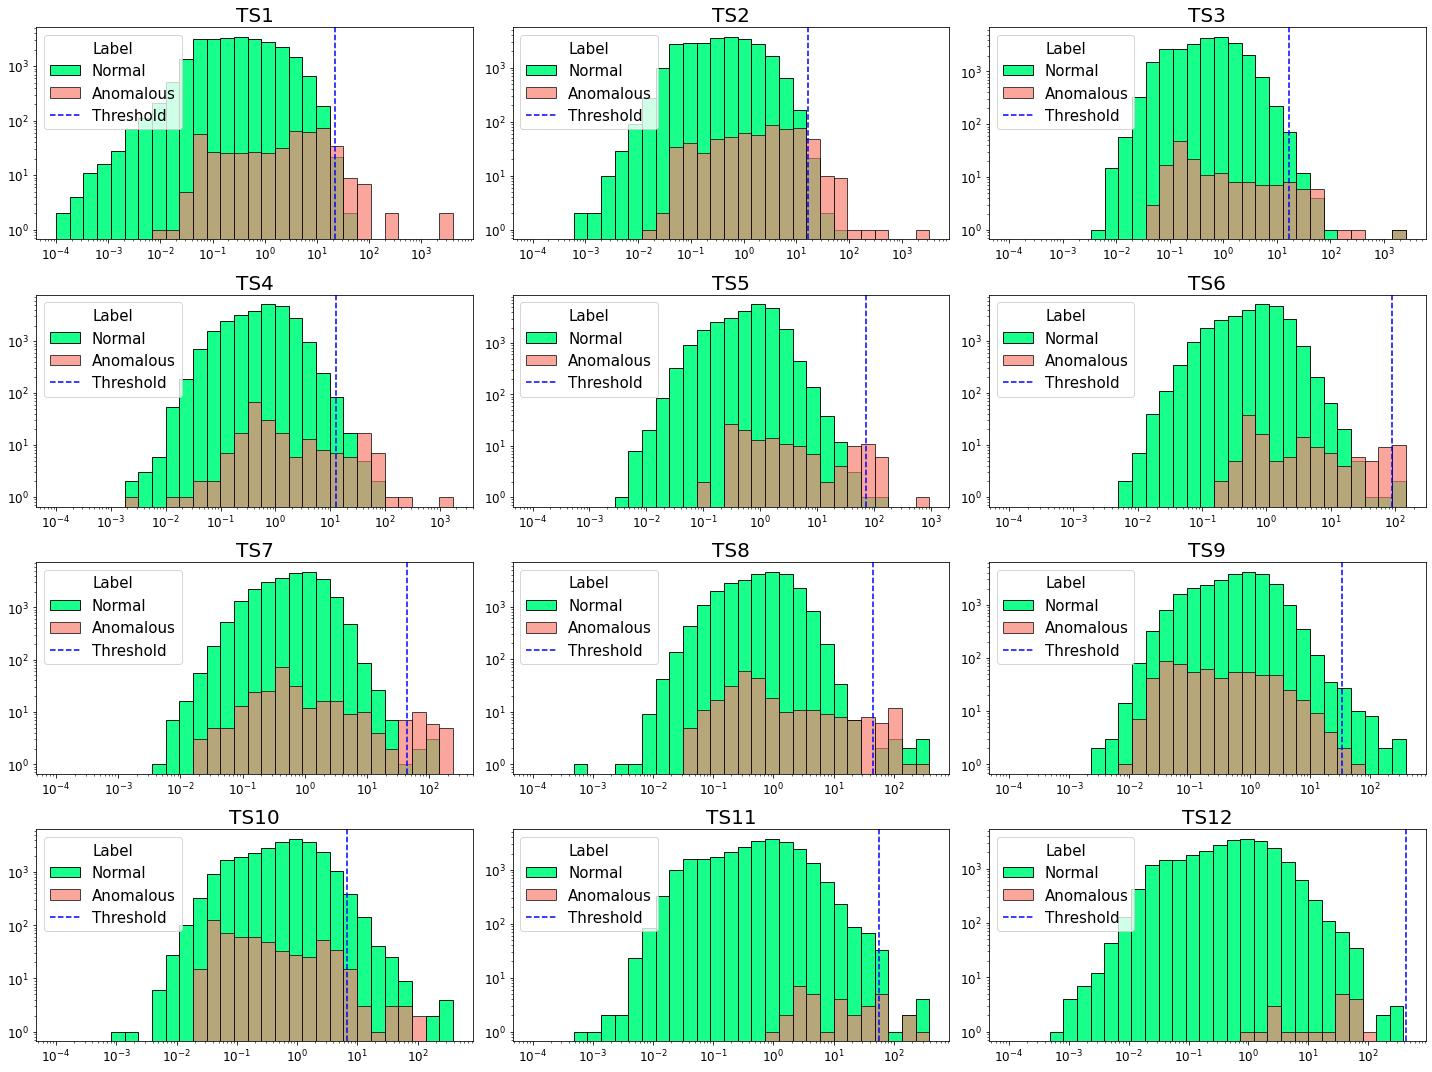

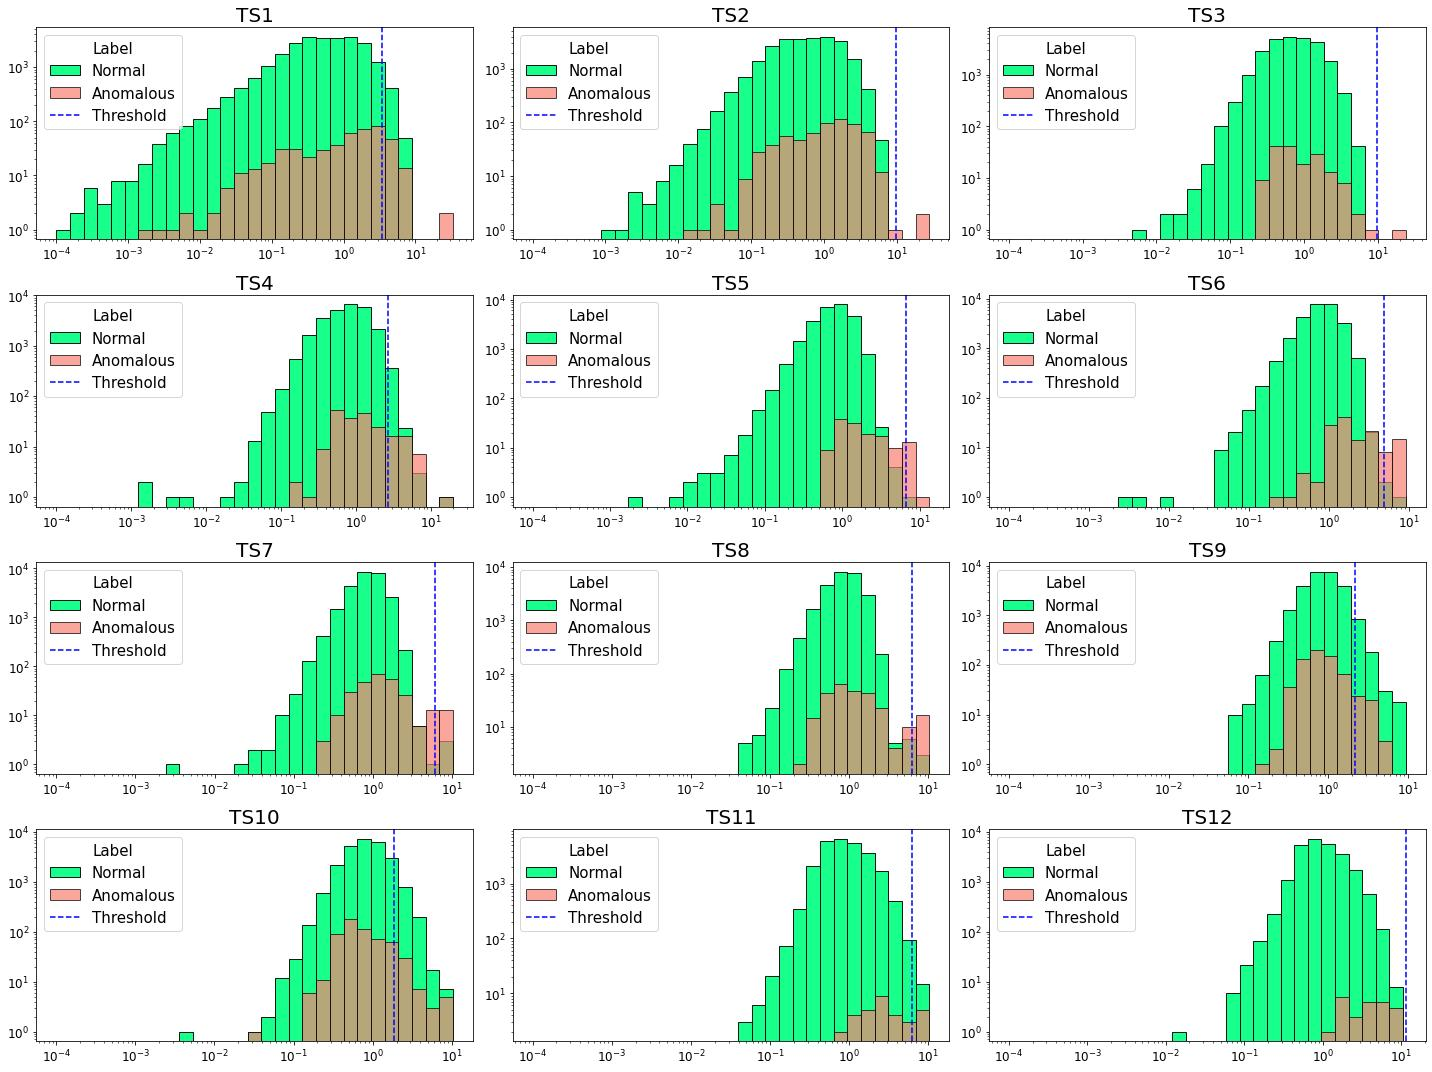

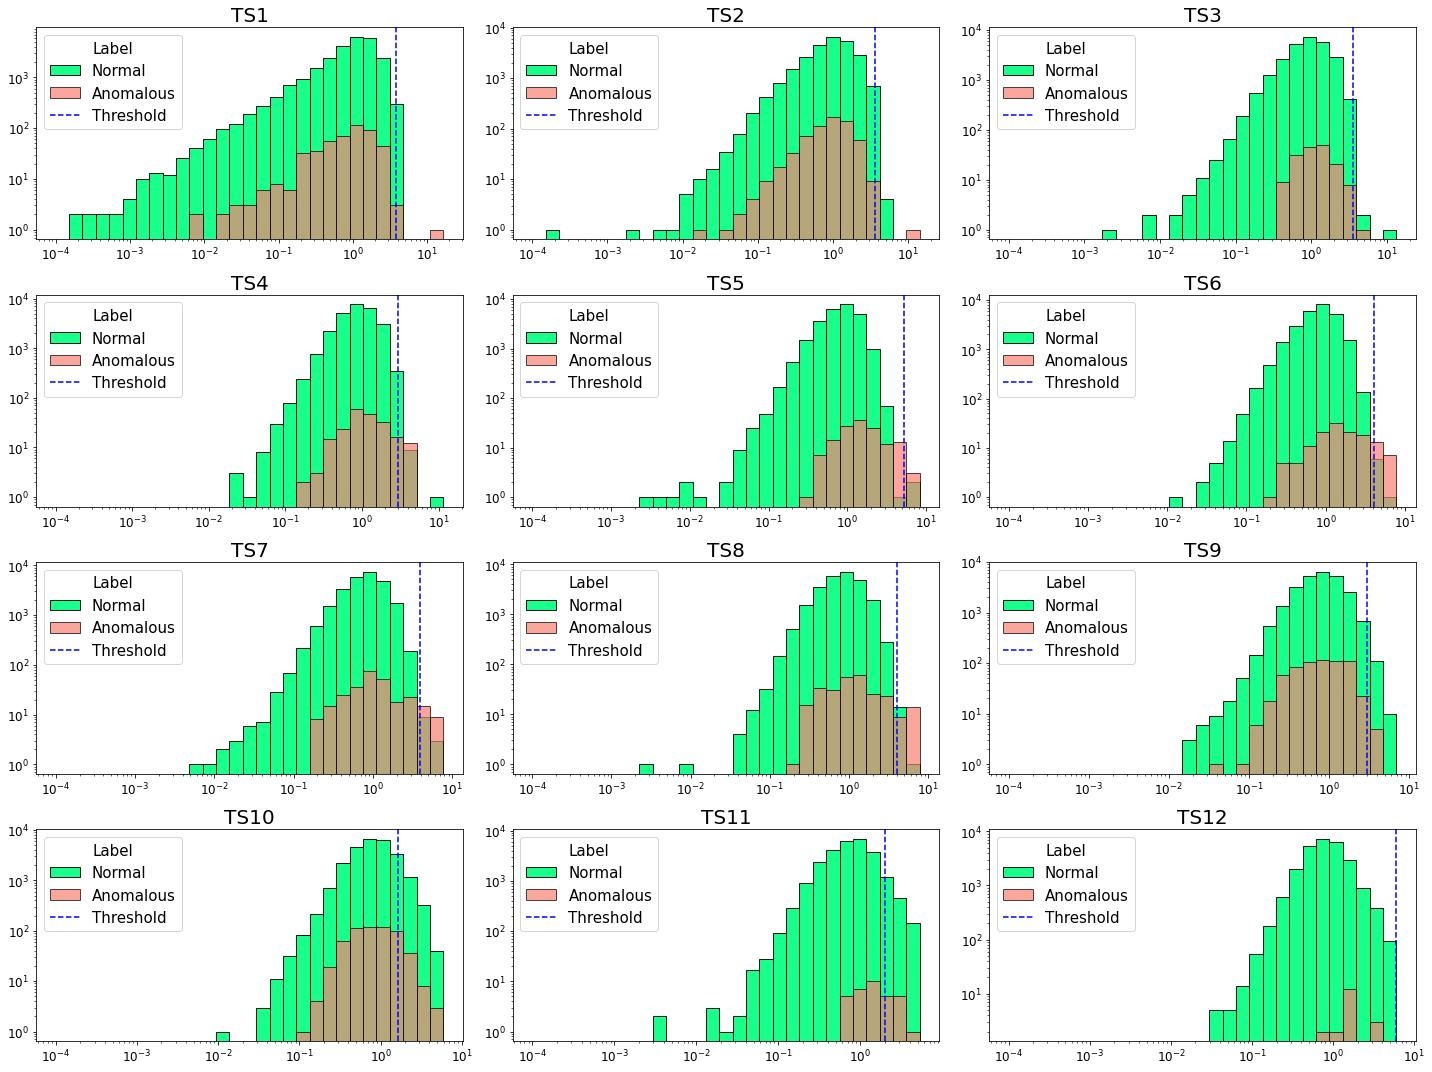

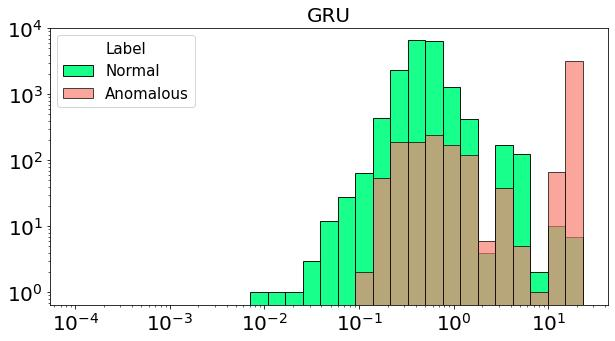

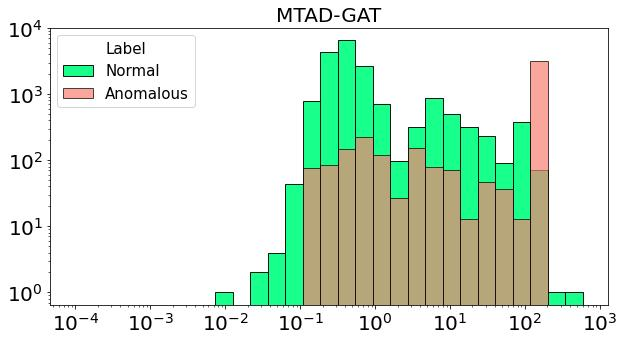

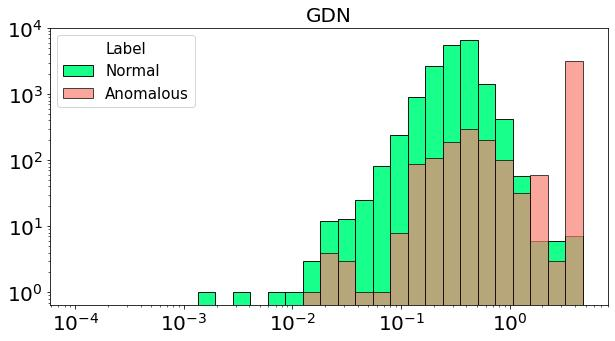

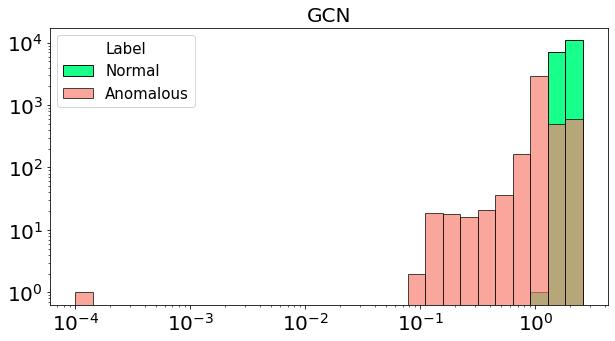

In [22]:
from gragod.metrics.visualization import plot_single_score_histogram, plot_score_histograms_grid_telco

figures = defaultdict(dict)

for datasets in ["telco", "swat"]:
    for model in ["gru", "mtad_gat", "gdn", "gcn"]:
        outputs = models_outputs[datasets][model]
        print(model)
        if datasets == "swat":
            figures[datasets][model] = plot_single_score_histogram(
                scores=outputs["scores_single"], 
                labels=outputs["labels_single"],
                metrics=None,
                use_ranged_anomalies=False,
                model_name=model.upper().replace("_", "-"),
                dataset_name=datasets,
            )
        elif datasets == "telco":
            figures[datasets][model] = plot_score_histograms_grid_telco(
                scores=outputs["scores"],
                labels=outputs["labels"],
                thresholds=outputs["threshold"],
                use_ranged_anomalies=False,
                metrics=None,
                log_axis=True
            )


In [23]:
# Save all in "anomaly_scores_histograms/{{dataset}}/{{model}}.png"
import shutil
if os.path.exists("anomaly_scores_histograms"):
    shutil.rmtree("anomaly_scores_histograms")
os.makedirs("anomaly_scores_histograms")
for dataset in figures.keys():
    os.makedirs(f"anomaly_scores_histograms/{dataset}")
    for model in figures[dataset].keys():
        figures[dataset][model].savefig(f"anomaly_scores_histograms/{dataset}/{model}.pdf")
